In [1]:
# Libraries
import os
import mne

# Qt backend is required for interactive MNE visualizations
from qtpy import QtWidgets

# To ensure that a Qt application exists --> necessary for MNE plots using PyQt
app = QtWidgets.QApplication.instance()
if app is None:
    app = QtWidgets.QApplication([])


# from mne import EpochsArray, create_info
# from mne import EvokedArray
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# # from collections import defaultdict

In [5]:
# Function: save_figure
# Purpose : to save all Matplotlib figures that are not MNEQtBrowser

def save_figure(fig, filename, folder="C:\\Users\\indira.lavocat\\MOVIDOC\\tictrack_eeg_analysis\\Figures-Patients"):
    # create folder if it does not exist
    if not os.path.exists(folder):
        os.makedirs(folder)
    # build the output path
    fig_path = os.path.join(folder, filename)
    # save the figure to the path
    fig.savefig(fig_path)
    # confirm to user that it has been done
    print(f"Figure saved: {fig_path}")


In [16]:
# ============================================================
# A. Data
# ============================================================


# ================
# 1. Load the data
# ================
FilePath = '/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack000010.vhdr'
#FilePath = "C:\\Users\\Indira.Lavocat\\MOVIDOC\\EEG\\EEG PATIENT FILES\\MOVIDOCTicTrack000010.vhdr" #DS26 done
# FilePath = "C:\\Users\\indira.lavocat\\MOVIDOC\\EEG\\EEG PATIENT FILES\\MOVIDOCTicTrack_BB28-bis.vhdr" #BB28 done
# FilePath = "C:\\Users\\indira.lavocat\\MOVIDOC\\EEG\\EEG PATIENT FILES\\MOVIDOCTicTrack000013.vhdr" #BC29 done
# FilePath = "C:\\Users\\indira.lavocat\\MOVIDOC\\EEG\\EEG PATIENT FILES\\MOVIDOCTicTrack000030.vhdr" #MM30 done
# FilePath = "C:\\Users\\indira.lavocat\\MOVIDOC\\EEG\\EEG PATIENT FILES\\MOVIDOCTicTrack000031.vhdr" #SC31 done


--- Test on file : MOVIDOCTicTrack000010.vhdr ---

Extracting parameters from /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack000010.vhdr...
Setting channel info structure...


/var/folders/r2/kf0b77n9367f1kyv8g58ss8m0000gp/T/ipykernel_7128/2256802773.py:11: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(FilePath, preload=True)


Reading 0 ... 837089  =      0.000 ...  1674.178 secs...
['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']
None
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S  4'), np.str_('Stimulus/S  5'), np.str_('Stimulus/S  6'), np.str_('Stimulus/S  7'), np.str_('Stimulus/S  8'), np.str_('Stimulus/S  9'), np.str_('Stimulus/S 10'), np.str_('Stimulus/S 11'), np.str_('Stimulus/S 12'), np.str_('Stimulus/S 13'), np.str_('Stimulus/S 14'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S 23'), np.str_('Stimulus/S 24'), np.str_('Stimulus/S 25'), np.str_('Stimulus/S 26'), np.str_('Stimulus/S 31'), np.str_('Stimulus/S 32'), np.str_('Stimulus/S 33'), np.str_('Stimulus/S 34'), np.str_('Stimulus/S 41'), np.str_('Stimulus/S 42'), np

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Using matplotlib as 2D backend.


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    1.1s finished


Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     50.00 : 10323 windows
Application REST referencial ...
Fitted sphere radius:         96.0 mm
Origin head coordinates:      -0.9 13.5 42.7 mm
Origin device coordinates:    -0.9 13.5 42.7 mm

Equiv. model fitting -> RV = 0.00406411 %%
mu1 = 0.943578    lambda1 = 0.140053
mu2 = 0.664225    lambda2 = 0.686726
mu3 = 0.0340156    lambda3 = -0.01641
Set up EEG sphere model with scalp radius    96.0 mm

EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    31 out of 31 channels remain after picking
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
First stimulus at 38.410 s

=== Annotations after the recalage ===
<Annotations | 167 segments: Stimulus/S 1 (1), Stimulus/S 2 (1), ...>

=== All the annotations labels ===
{np.str_('Stimulus/S  9'), np.str_

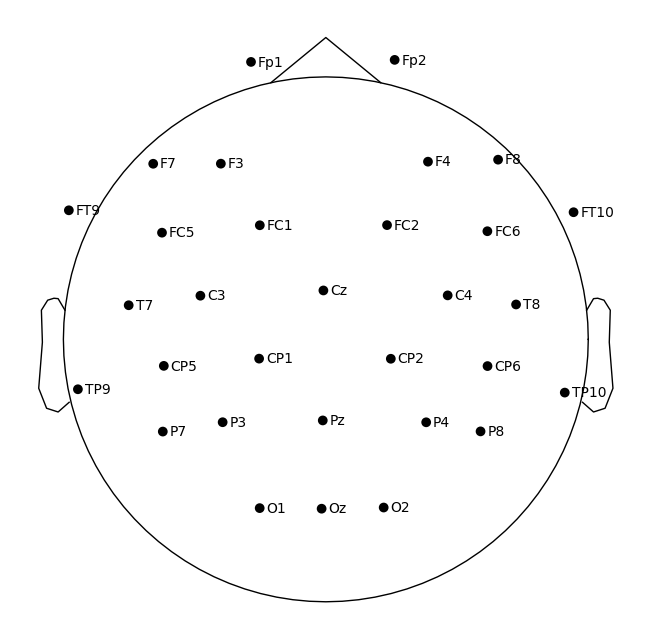

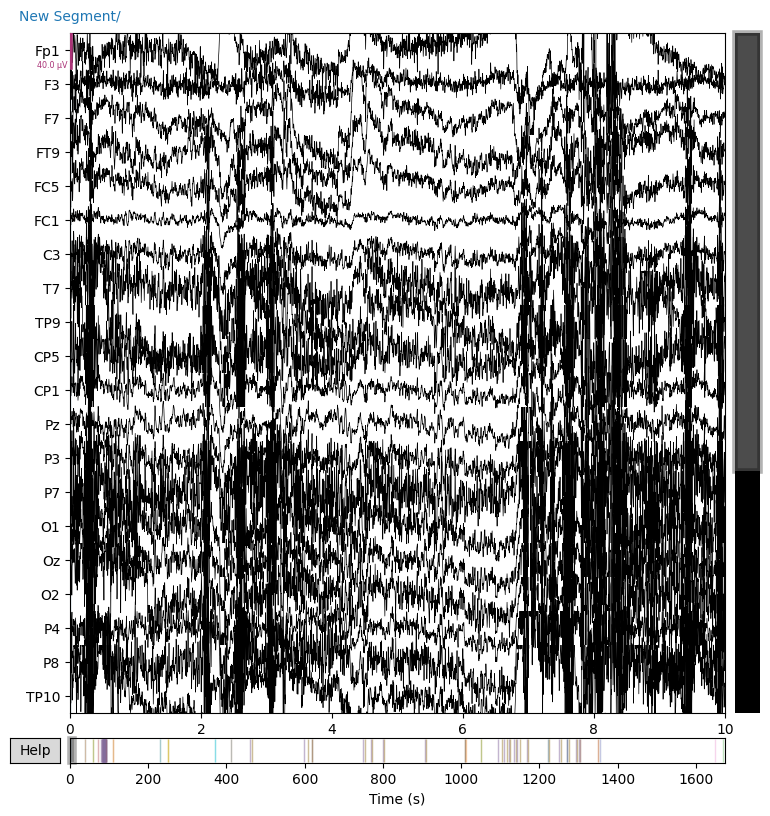

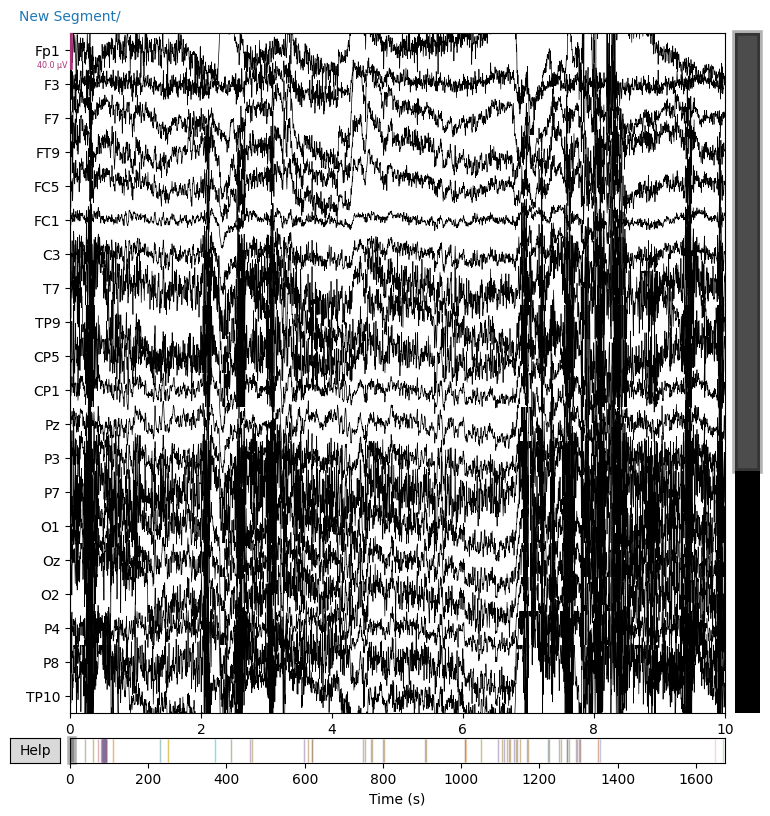

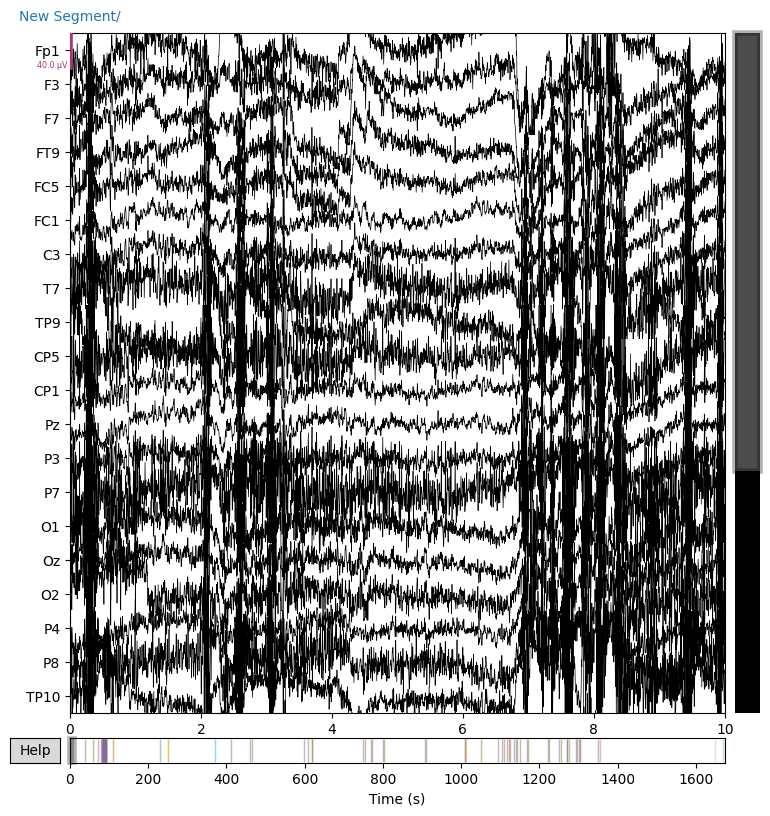

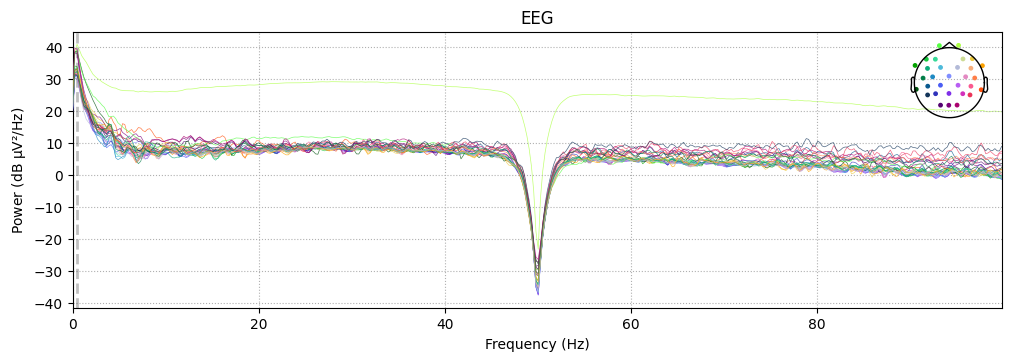

In [17]:
try:
    # extract the filename only
    filename = os.path.basename(FilePath)
    # remove the fixed prefix & suffix to extract the subject identifier
    subject_name = filename.replace("_annotations_binary-table_cutted.xlsx", "").replace(".xlsx", "")
    #subject_name = filename.replace("MOVIDOCTicTrack", "").replace(".vhdr", "")
    # display the file that is being processed
    print(f"\n--- Test on file : {subject_name} ---\n")

    # load the BrainVision data in memory
    raw = mne.io.read_raw_brainvision(FilePath, preload=True)
    # print the useful info
    raw.info
    print(raw.ch_names)
    print(raw.info['description'])


    # ======================
    # 2. Extract the stimuli
    # ======================

    # extract the events & their IDs from BrainVision annotations
    events, event_id = mne.events_from_annotations(raw)
    print("Events list (stimulus) :")
    print(event_id)
    print("Events (sample, previous_id, event_id) :")
    print(events) # array: columns = [sample, 0, event_code]

    # remove the events that occur at sample index 0 (non-informative)
    events_no_zero = events[events[:, 0] != 0]
    # convert the event sample indices to time (in seconds)
    events_times_sec = events_no_zero[:, 0] / raw.info['sfreq']

    # print a readable list of the events with timestamps
    for time, eid in zip(events_times_sec, events_no_zero[:, 2]):
        print(f"Stimulus {eid} à {time:.3f} s")
    id_to_name = {v: k for k, v in event_id.items()}
    for time, eid in zip(events_times_sec, events_no_zero[:, 2]):
        print(f"{id_to_name.get(eid, eid)} à {time:.3f} s")
    


    # ============================================================
    # B. Preprocessing
    # ============================================================


    # =====================
    # 1. Define the montage
    # =====================

    # apply the standard 10–20 electrode positions => to adapt if another montage used during the experiment
    raw.set_montage("standard_1020")
    # visualize the electrode placement
    Sensors_Montage_Fig = raw.plot_sensors(show_names=True, show=False)


    # ===================================
    # 2. Filter the data with a band-pass
    # ===================================

    # define the limits of the filter to apply
    HFreq = 100
    LFreq = 0.5
    # apply band-pass filter between 0.5 and 100 Hz
    raw_HighLowPassed = raw.filter(l_freq = LFreq, h_freq = HFreq)
    # visualize the band-passed signal
    Signal_HighLowPassed_Figure_2 = raw_HighLowPassed.plot(title = "High- and Low- passed Signal", show=False)


    # ===============================
    # 3. Filter the data with a Notch
    # ===============================

    # apply Notch filter at 50 Hz to remove the powerline noise
    if HFreq < 50:
        raw_Notched = raw_HighLowPassed
    else:
        raw_Notched = raw_HighLowPassed.notch_filter(freqs = [50], picks = "data", method = "spectrum_fit")
    # visualize the notched signal
    Signal_Notched_Figure_3 = raw_Notched.plot(title = "Notched Signal", show=False)


    # ============================
    # 4. Identify the bad channels
    # ============================


    # ========================
    # 5. Re-reference the data
    # ========================

    print("Application REST referencial ...")
    # build an anatomical sphere model for the REST computation
    Sphere = mne.make_sphere_model('auto', 'auto', raw_Notched.info)
    # create a volume source space inside this sphere
    Source = mne.setup_volume_source_space(sphere=Sphere, exclude=30.0, pos=5.0, mri=None, verbose=False)
    # compute the forward model for referencing
    Forward = mne.make_forward_solution(raw_Notched.info, trans=None, src=Source, bem=Sphere, verbose=False)
    # apply the REST referencing
    raw_REST = raw_Notched.copy().set_eeg_reference('REST', forward=Forward)
    # visualize the re-referenced signal
    Signal_REST_Figure_4 = raw_REST.plot(title="Signal après référence REST", show=False)
    # visualize the PSD of the re-referenced signal
    Signal_REST_PSD_Figure_4_bis = raw_REST.plot_psd(fmin=0, fmax=100, show=False) # PSD = Power Spectrum Density

    # ===========
    # 6. Recalage
    # ===========

    # some BrainVision files place the 1st annotation at t=0 → for those, verify that they have a 2nd one, and if so, use it (instead of the 1st)
    if events_times_sec[0] == 0 and len(events_times_sec) > 1: # if the 1st annotation at t=0 & a 2nd annotation exists,
        first_stimulus_time = events_times_sec[1] # use the 2nd event
        print(f"First stimulus is at 0. Using second stimulus at {first_stimulus_time:.3f} s")
    else:
        first_stimulus_time = events_times_sec[0] # use the 1st event normally
        print(f"First stimulus at {first_stimulus_time:.3f} s")
    
    # crop the signal from this timestamp
    raw_cropped = raw_REST.copy().crop(tmin=first_stimulus_time)

    # re-align the annotations relative to the new t=0
    if raw_REST.annotations is not None:
        # shift all the annotation onsets backward by the cropping time
        ### raw_annotation_times = raw.annotations.onset - first_stimulus_time
        onset_times = raw_REST.annotations.onset - first_stimulus_time
        # determine which annotations occur AFTER cropping
        mask_valid = onset_times >= 0
        # replace the annotations in the cropped raw object
        raw_cropped.set_annotations(
            mne.Annotations(
                onset=onset_times[mask_valid], # shifted onsets
                duration=raw_REST.annotations.duration[mask_valid], # original durations
                description=[d for d, valid in zip(raw_REST.annotations.description, mask_valid) if valid] # descriptions
            )
        )
        print("\n=== Annotations after the recalage ===")
        print(raw_cropped.annotations)

        print("\n=== All the annotations labels ===")
        print(set(raw_cropped.annotations.description))



    # ============================================================
    # C. Epoching
    # ============================================================


    # =======================================
    # 1. Phases dictionnary (with TTL limits)
    # =======================================

    # define the TTL names for each phase of the experiment
    phases_dict = {
        "spontaneous_tics": {"start": "Stimulus/S  9", "end": "Stimulus/S 10"},
        "imitated_tics": {"start": "Stimulus/S 11", "end": "Stimulus/S 12"},
        "retention_tics": {"start": "Stimulus/S 13", "end": "Stimulus/S 14"}
    }


    # =====================
    # 2. Go over each phase
    # =====================
    
    # iterate through each phase
    for phase_name, phase_TTL in phases_dict.items():
        try:
            # Get the beginning & end timestamps based on the annotations
            annotations = raw_cropped.annotations
            # extract timestamps for the start & end TTL of the phase
            start_times = [ann['onset'] for ann, desc in zip(annotations, annotations.description) if desc == phase_TTL['start']]
            end_times = [ann['onset'] for ann, desc in zip(annotations, annotations.description) if desc == phase_TTL['end']]
    
            # if phase markers are missing → skip
            if len(start_times) == 0 or len(end_times) == 0:
                print(f"Phase {phase_name} not found for {subject_name}, missing TTL")
                continue
                
            # use the 1st occurrence of the start & end TTL of the phase
            start_time = start_times[0]
            end_time = end_times[0]

            print(f"{phase_name}: {start_time:.2f}s → {end_time:.2f}s")

            end_time = min(end_times[0], raw_cropped.times[-1])

            # crop the signal to isolate the phase
            phase_raw = raw_cropped.copy().crop(tmin=start_time, tmax=end_time)

            # Save the file for this phase
            folder_phase = "C:\\Users\\indira.lavocat\\MOVIDOC\\tictrack_eeg_analysis\\EEG_Phases"
            if not os.path.exists(folder_phase):
                os.makedirs(folder_phase)

            # build the output filename
            phase_file_path = os.path.join(folder_phase, f"{subject_name}_{phase_name}_raw.fif")
            # save the cropped phase as a .fif file
            phase_raw.save(phase_file_path, overwrite=True)
            print(f"Saved phase : {phase_file_path}")

        except Exception as e:
            # catch & report any unexpected error
            print(f"Error while cutting the phase {phase_name} for {subject_name} : {e}")
            continue


except Exception as e:
    print(f"❌ Error: {e}")